# Install the Project requirements
this installs matplotlib and other necessary dependencies
you must have UV installed, use pip or your linux package manager

In [ ]:
!uv sync

Resolved 62 packages in 0.65ms
Uninstalled 3 packages in 4ms
Installed 29 packages in 120ms
 + certifi==2026.5.20
 + charset-normalizer==3.4.7
 + click==8.4.1
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + idna==3.18
 - ipykernel==7.3.0
 + ipykernel==7.2.0
 + joblib==1.5.3
 - jupyter-client==8.9.1
 + jupyter-client==8.9.0
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + narwhals==2.22.1
 + nest-asyncio==1.6.0
 - nest-asyncio2==1.7.2
 + nltk==3.9.4
 + numpy==2.4.6
 + pandas==3.0.3
 + pillow==12.2.0
 + pyparsing==3.3.2
 + pyyaml==6.0.3
 + regex==2026.5.9
 + requests==2.34.2
 + scikit-learn==1.9.0
 + scipy==1.17.1
 + seaborn==0.13.2
 + threadpoolctl==3.6.0
 + tqdm==4.68.2
 + urllib3==2.7.0
 + wordcloud==1.9.6


# Get the data from the API
will request you to enter your secret key to get the data from the API
This will also import all required libaries

In [11]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# Self coded API intergration for Data Exploration
from API import GovApi,Search
API = GovApi()
# Libaries for plotting data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

newSearch = Search()
newSearch.constituency = "Beaconsfield"

data = API.get_data(Search.path,**newSearch.params)
# data

200


# Data Pre-Processing

In [89]:
import re
class PreProcess :
    
    LEMMITIZER = WordNetLemmatizer()
    ADDRESS_COLS = ["addressLine1", "addressLine2", "addressLine3", "addressLine4"]

    @classmethod
    def clean(cls,data_frame : pd.DataFrame) -> pd.DataFrame:
        print(data_frame.duplicated().sum())
        # Remove exact duplicates
        data_frame = data_frame.drop_duplicates()
        data_frame = data_frame.dropna(subset=["currentEnergyEfficiencyBand"])

        return data_frame
    
# Feature engineering - using nltk
    @classmethod
    def make_full_address(cls,data_frame : pd.DataFrame) -> pd.DataFrame:
        # Sort by date - to make sure the certificates that are most up to date are used.

        data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
        data_frame.sort_values(by="registrationDate")

        data_frame["FullAddress"] = (
            data_frame[cls.ADDRESS_COLS]
            .fillna("")
            .agg("\n ".join, axis=1)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

        return cls.drop_unnecessary_cols(data_frame,addressLines=True)
    @classmethod
#
    def drop_address_duplicates(cls,data_frame : pd.DataFrame) -> pd.DataFrame:
        # 74 for postcode, 153 for full address
        data_frame = data_frame.drop_duplicates(subset=['FullAddress'], keep='first')

        return data_frame
    @classmethod
    def format_words(cls, text :str) -> list[str]:
        # Lowercase conversion
        text = text.lower()

        # Remove special characters
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Tokenize the text
        tokens = word_tokenize(cleaned_text)

        stop_words = set(stopwords.words('english'))
        formatted_words = [cls.LEMMITIZER.lemmatize(word) for word in tokens if word.lower() not in stop_words]

        return formatted_words

    # Remove dupes based on postcode - removes buildings that might not necessarily be dupes but buildings under the same post
    # Another edge case could be PO Boxes are used instead
    @classmethod
    def postcode_duplicates(cls, data_frame : pd.DataFrame) -> pd.DataFrame:
        data_frame = data_frame.drop_duplicates(subset=['postcode'], keep='first')
        return data_frame
    
    @classmethod
    def drop_unnecessary_cols(cls, data_frame : pd.DataFrame,addressLines=False) -> pd.DataFrame:
        if addressLines :
            return data_frame.drop(cls.ADDRESS_COLS,axis="columns")
        else :
            return data_frame.drop(["tokens","registrationYear"],axis="columns",errors="ignore")
        


data_frame = pd.DataFrame(data['data'])
print(data_frame.isna().sum())
# data_frame.shape 678
data_frame = PreProcess.clean(data_frame)
data_frame = PreProcess.make_full_address(data_frame)
data_frame = PreProcess.drop_address_duplicates(data_frame)
# data_frame.shape 153

certificateNumber                0
addressLine1                   248
addressLine2                     6
addressLine3                   114
addressLine4                   508
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      2
registrationDate                 0
uprn                            31
schemaType                       0
dtype: int64
0


# Data Exploration

In [3]:
# First few columns
data_frame = data_frame.sort_values(by="currentEnergyEfficiencyBand")
data_frame.head()

,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType,FullAddress
23,2873-1010-5628-4590-6625,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2026-02-02,1.009653e+10,CEPC-8.0.0,New Sports Hall Sir William Borlase's Grammar ...
223,9997-0251-2119-8154-8890,The Beacon Centre,Beacon Close,NaN,NaN,HP9 1RJ,BEACONSFIELD,Buckinghamshire,Beaconsfield,A,2021-11-19,1.000812e+11,CEPC-8.0.0,The Beacon Centre Beacon Close
12,3542-6814-3342-2090-2592,Iver Heath Junior School,St Margaret's Close,Iver Heath,Buckinghamshire,SL0 0DA,Iver Heath,Buckinghamshire,Beaconsfield,B,2026-03-20,NaN,CEPC-8.0.0,Iver Heath Junior School St Margaret's Close I...
14,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Front) Spinfield School Terring...
13,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Rear) Spinfield School Terringt...


In [4]:
# shape of the data (rows,columns)
data_frame.shape

(152, 14)

In [6]:
# testing postcodes pre processing
newSearch = Search()
newSearch.postcode = "SL7 2RE" # has multiple buildings and multiple certificates
data = API.get_data(Search.path,**newSearch.params)

test_data_frame = pd.DataFrame(data['data'])
test_data_frame = PreProcess.clean(test_data_frame) # there are earlier certificates that show it having C effeciency instead of B
data_frame = PreProcess.make_full_address(test_data_frame)
PreProcess.drop_address_duplicates(test_data_frame)


200
0


,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType,FullAddress
0,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0,Main Building (Rear) Spinfield School Terringt...
1,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0,Main Building (Front) Spinfield School Terring...
2,2968-8515-4252-3592-6806,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2025-02-11,100081278527,CEPC-8.0.0,Spinfield School Terrington Hill


In [11]:
# check for missing values
data_frame.isnull().sum()

certificateNumber                0
addressLine1                    44
addressLine2                     1
addressLine3                    42
addressLine4                   115
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      0
registrationDate                 0
uprn                             4
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

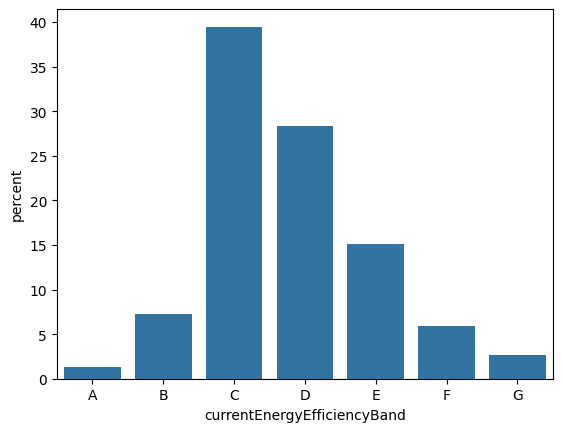

In [12]:

# check distribution of target variable
sns.countplot(data=data_frame, x="currentEnergyEfficiencyBand", stat="percent")

# Compare the constituency Beaconsfield to London

In [13]:
newSearch = Search()
newSearch.constituency = "Cities of London and Westminster"

data = API.get_data(Search.path,**newSearch.params)
next_data_frame = PreProcess.clean(pd.DataFrame(data['data']))

next_data_frame = PreProcess.make_full_address(next_data_frame)
next_data_frame = PreProcess.drop_address_duplicates(next_data_frame)


200
0


In [12]:
# London Shape
next_data_frame.shape

(988, 14)

In [14]:
next_data_frame.isnull().sum()

certificateNumber                0
addressLine1                   420
addressLine2                    54
addressLine3                   368
addressLine4                   917
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      0
registrationDate                 0
uprn                           153
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

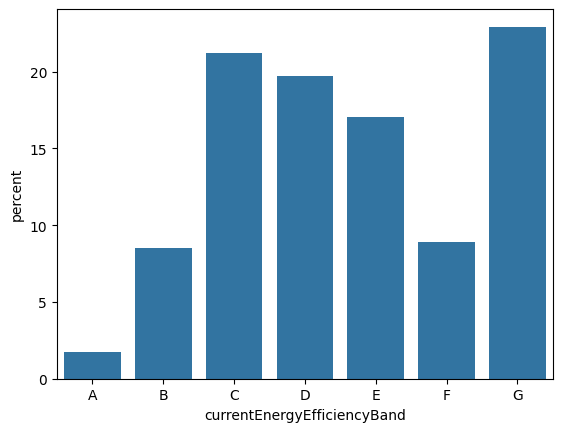

In [15]:
sns.countplot(data=next_data_frame.sort_values(by="currentEnergyEfficiencyBand"), x="currentEnergyEfficiencyBand", stat="percent")

In [15]:
# sub-urban vs urban data 
full_data = pd.concat([data_frame,next_data_frame],ignore_index=True).sort_values(by="currentEnergyEfficiencyBand")
full_data.shape

(1140, 14)

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='proportion'>

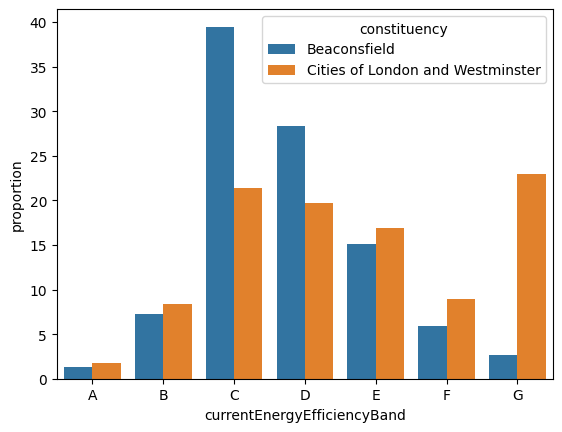

In [16]:
# Make beaconsfield proportionate to london to do an efficiency comparison
comparison = full_data.groupby("constituency")["currentEnergyEfficiencyBand"].value_counts(normalize=True).mul(100).sort_index().reset_index().sort_values(by="currentEnergyEfficiencyBand")

sns.barplot( data=comparison, x="currentEnergyEfficiencyBand", y="proportion", hue="constituency")
# sns.countplot(data=new, x="currentEnergyEfficiencyBand", stat="percent",hue="constituency")

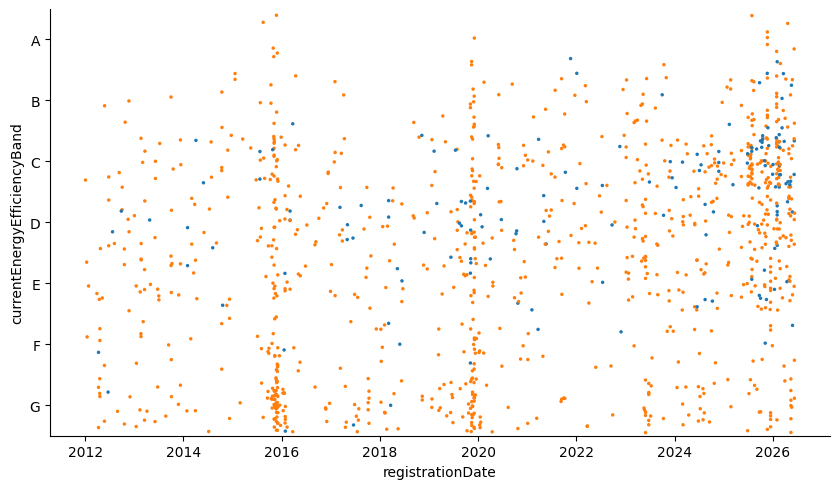

In [17]:
# Are buildings that have registered earlier more or less energy efficent?

full_data["registrationDate"] = pd.to_datetime(full_data["registrationDate"])
full_data["registrationYear"] = full_data["registrationDate"].dt.year
table = sns.catplot(
    data=full_data,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    hue="constituency",
    size=2.5,
    legend=False,
    aspect=1.7
)

table

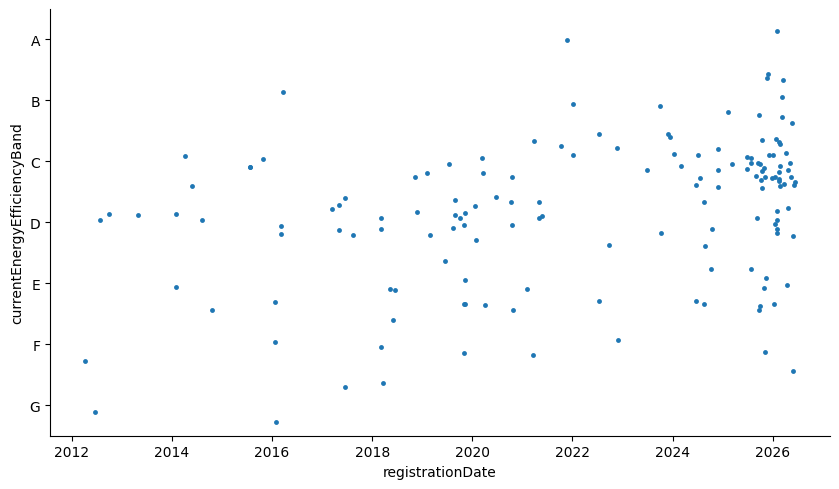

In [11]:
# beaconsfield only

data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
data_frame["registrationYear"] = data_frame["registrationDate"].dt.year
table = sns.catplot(
    data=data_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    size=3.5,
    legend=False,
    aspect=1.7
)

# Feature Engineering with NLP
This first step is to download and install all nltk requirements

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# !uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0.tar.gz

# import spacy
# NLP = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [92]:
# Make a new data frame that will include buildings so that older certificates are in the data
newSearch = Search()
newSearch.constituency = "Beaconsfield"

data = API.get_data(Search.path,**newSearch.params)

data_frame = pd.DataFrame(data['data']).sort_values(by="currentEnergyEfficiencyBand")
print(data_frame.shape) #678
data_frame = PreProcess.clean(data_frame)
data_frame = PreProcess.make_full_address(data_frame)

200
(678, 13)
0


In [95]:
# print(hasattr(PreProcess, "remove_stopwords"))
# print(dir(PreProcess))

# Only include 1 building per feature
# data_frame = PreProcess.postcode_duplicates(data_frame) - if buildings have multiple certificates this still wont work.
print(data_frame.shape)

data_frame['tokens'] = data_frame["FullAddress"].apply(PreProcess.format_words)

from nltk import ngrams

N = 2 

building_descriptor = {"combined",
    "primary", "secondary", "junior", "infant", "grammar", "ce", # ce - church of england
    "catholic", "community", "sport", "police", "fire", "medical", 
    "health", "youth", "delivery", "county", "fire", "business","court" , "leisure"
}
building_types = {
    "school","centre","station","office","council", "college",
    "hospital","surgery","library","academy","court",
    "hall","church","nursery","house","complex", "department"
}

def extract_features(tokens):

    bigrams = ngrams(tokens, N)

    for wDesc, wType in bigrams:

        if wDesc == wType:
            continue

        if wType in building_types and wDesc in building_descriptor:
            features = f"{wDesc} {wType}"
            return features
        
    for unigrams in tokens :

        if unigrams in building_types :
            return unigrams

    return None

data_frame["BuildingType"] = data_frame["tokens"].apply(extract_features)

# data_frame.isnull().sum() # only 11 missing building types

normalise = {
    "academy": "school",
    "primary academy": "primary school",
    "secondary academy": "secondary school",
    "medical centre": "hospital",
    "surgery": "hospital",
    "sport hall": "sport centre",
    "community hospital" : "hospital"
}

data_frame["BuildingType"] = data_frame["BuildingType"].replace(normalise)
  


(676, 12)


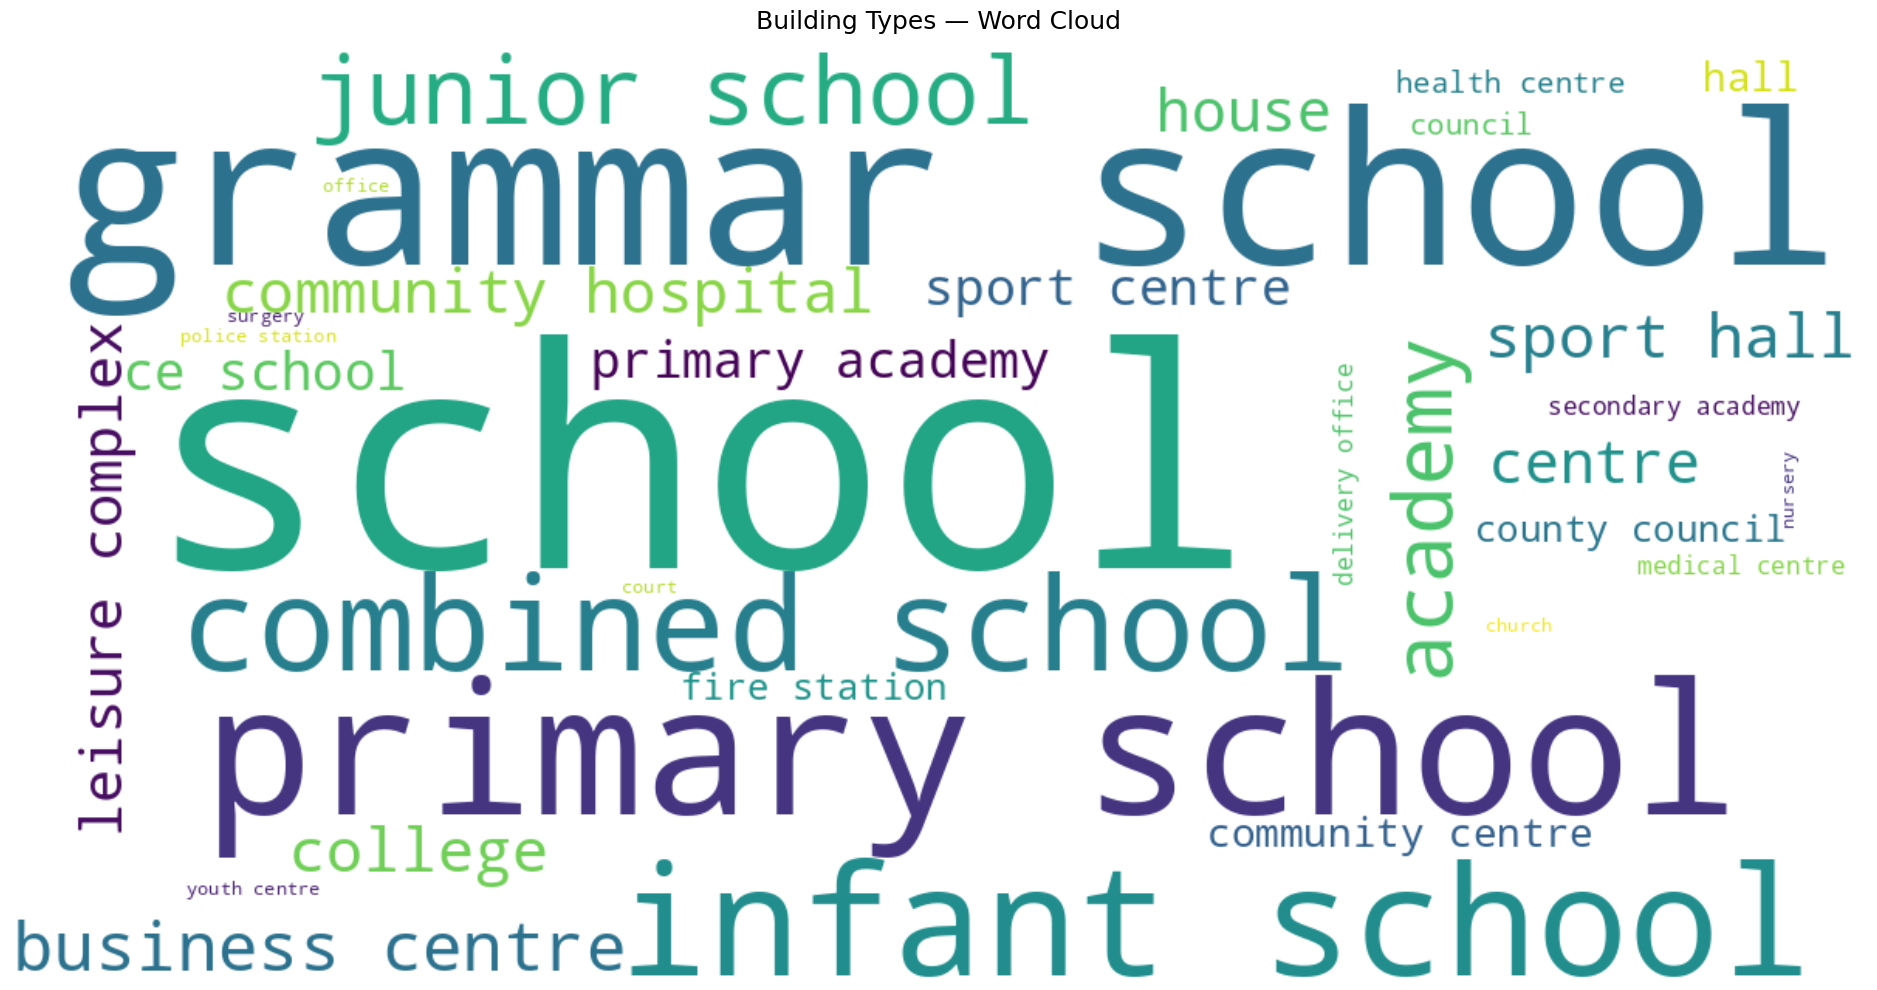

In [79]:
from wordcloud import WordCloud

building_type_counts = data_frame["BuildingType"].value_counts().to_dict()

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_font_size=200,
    min_font_size=12,
    prefer_horizontal=0.85
).generate_from_frequencies(building_type_counts)

figure, ax = plt.subplots(figsize=(20, 10))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Building Types — Word Cloud", fontsize=18, pad=16)
plt.tight_layout()
plt.show()

In [80]:
# check for missing values
data_frame.isnull().sum()

certificateNumber               0
postcode                        0
postTown                        0
council                         0
constituency                    0
currentEnergyEfficiencyBand     0
registrationDate                0
uprn                           31
schemaType                      0
FullAddress                     0
tokens                          0
BuildingType                    6
dtype: int64

In [96]:
data_frame.value_counts(subset=["BuildingType"])

BuildingType    
school              220
grammar school       72
primary school       63
infant school        51
combined school      47
junior school        41
sport centre         27
business centre      20
hospital             19
college              16
centre               15
house                15
leisure complex      14
ce school            12
community centre      6
hall                  6
fire station          5
county council        5
health centre         3
council               3
delivery office       2
secondary school      2
office                1
court                 1
police station        1
nursery               1
church                1
youth centre          1
Name: count, dtype: int64

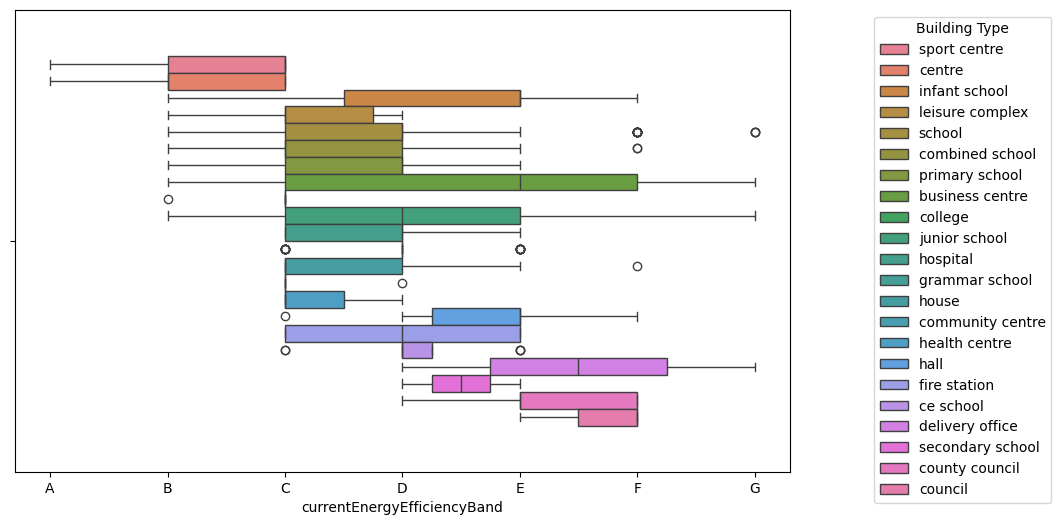

In [97]:
data_frame = data_frame.dropna(subset=["FullAddress"])
data_dy_frame = data_frame.groupby("BuildingType").filter(lambda x: len(x) > 1)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_dy_frame,hue="BuildingType",x='currentEnergyEfficiencyBand')
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', title="Building Type")
plt.show()

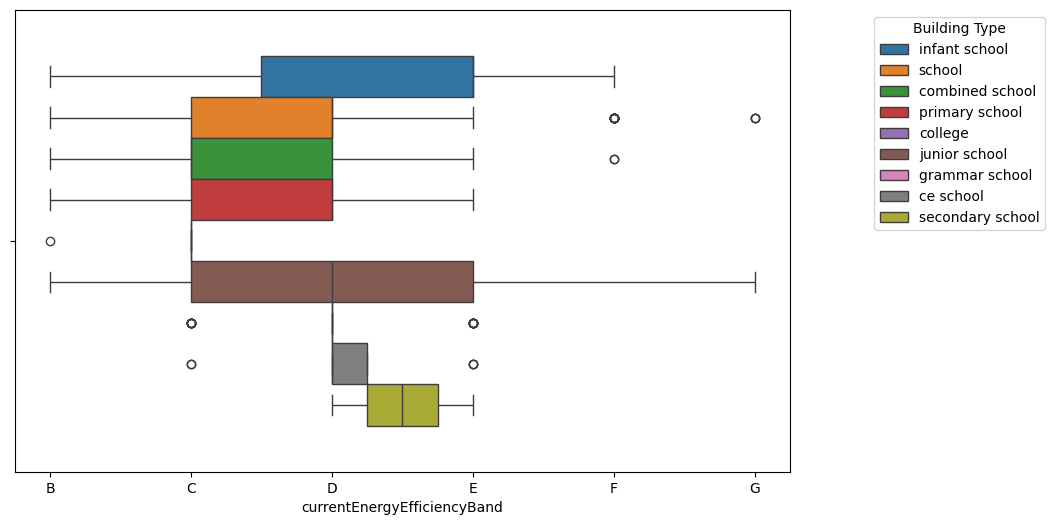

In [98]:
# schools only
school_frame = data_frame.groupby("BuildingType").filter(lambda x: x["BuildingType"].str.contains("school|college|academy").any())
plt.figure(figsize=(10, 6))
sns.boxplot(data=school_frame,hue="BuildingType",x='currentEnergyEfficiencyBand')
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', title="Building Type")
plt.show()

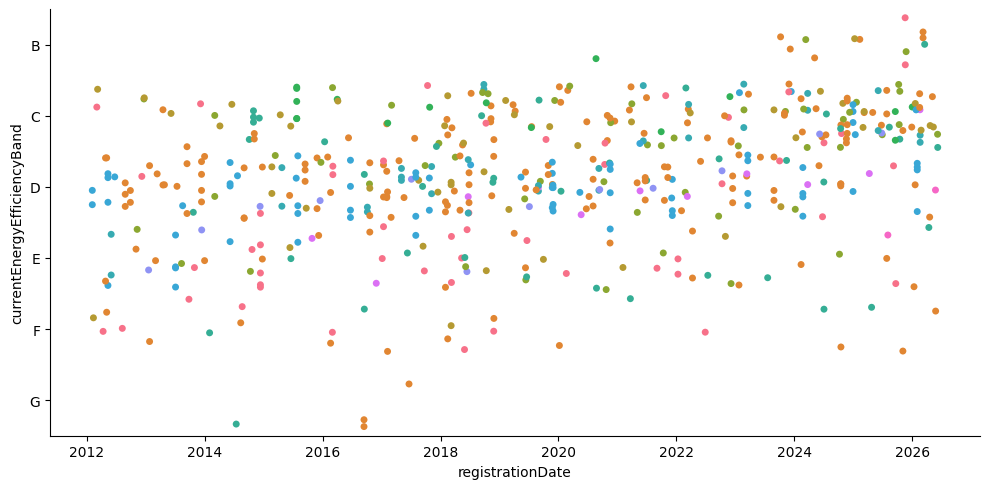

In [84]:
school_frame["registrationDate"] = pd.to_datetime(school_frame["registrationDate"])
school_frame["registrationYear"] = school_frame["registrationDate"].dt.year
table = sns.catplot(
    data=school_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand",
    hue="BuildingType",
    native_scale=True,
    jitter=0.45,
    kind="strip",
    legend= False,
    height=5,
    aspect=2
)

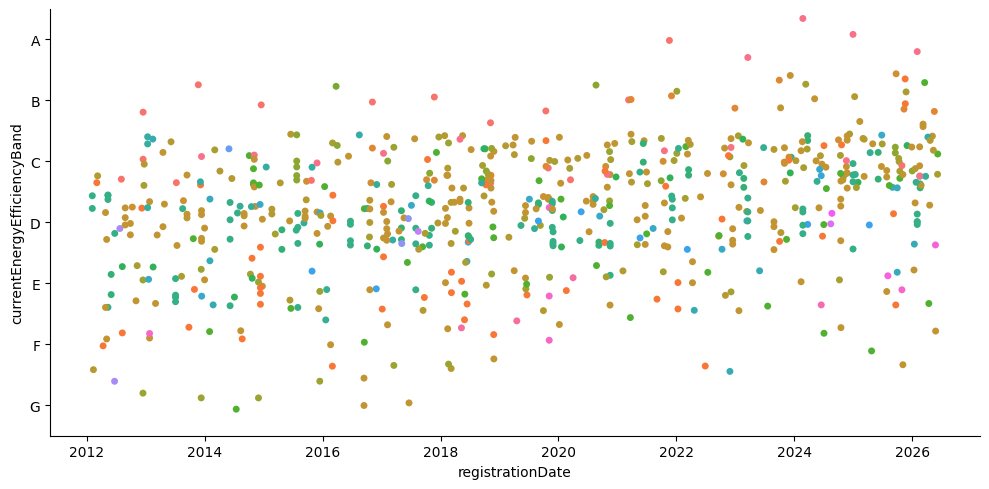

In [85]:
data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
data_frame["registrationYear"] = data_frame["registrationDate"].dt.year
table = sns.catplot(
    data=data_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand",
    hue="BuildingType",
    native_scale=True,
    jitter=0.45,
    kind="strip",
    legend= False,
    height=5,
    aspect=2
)

In [91]:
print(data_frame.columns.tolist()) 

['certificateNumber', 'postcode', 'postTown', 'council', 'constituency', 'currentEnergyEfficiencyBand', 'registrationDate', 'uprn', 'schemaType', 'FullAddress']


In [90]:
# to view all data and debug
data_frame = PreProcess.drop_unnecessary_cols(data_frame)
data_frame.to_csv("All-data.csv", sep='\t')

# Machine learning
predictions are made until 2028 using Logistic Regression
The red curve is a polynomial fit showing how the buildings energy efficency may begin to improve.

In [99]:
# Define reused functions

import numpy as np
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn import datasets, model_selection, metrics

BAND_ORDER = ['G', 'F', 'E', 'D', 'C', 'B']
label_encoder = LabelEncoder()

MODEL = LogisticRegression(max_iter=80)
# multi_class='multinomial', solver='lbfgs' - on by default
    # saga has 35% ≈ score
    # lbfgs has 50% ≈ score
    # standard logistic regression uses binomial
#

def train_model(X, y) :
    x_train, x_test, y_train, y_test = model_selection.train_test_split(
        X, y, random_state=42
    )

    MODEL.fit(x_train, y_train)

    y_pred = MODEL.predict(x_test)
    scores = f"""Scoring for model training:\n
    Accuracy score  : {metrics.accuracy_score(y_test,y_pred)}
    F1 score        : {metrics.f1_score(y_test,y_pred,average="micro")}
    Model score     : {MODEL.score(x_test,y_test)}
    """
    print(scores)

def label_encode(values) :
    label_encoder.classes_ = np.array(BAND_ORDER)
    return label_encoder.transform(values)

Scoring for model training:

    Accuracy score  : 0.44274809160305345
    F1 score        : 0.44274809160305345
    Model score     : 0.44274809160305345
    
                  MeanCoefficient
infant school              0.5606
college                    0.5392
grammar school             0.5046
ce school                  0.2916
primary school             0.2900
school                     0.2887
junior school              0.2449
combined school            0.2339
secondary school           0.1962


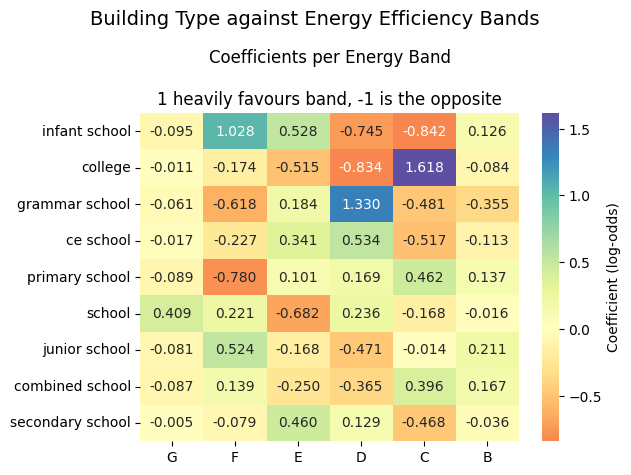

In [100]:
from sklearn.preprocessing import OneHotEncoder

def feature_importance(data_frame):
    
    # One-hot encode for BuildingType
    # Building types have no order
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X = ohe.fit_transform(data_frame[['BuildingType']])
    building_categories = ohe.categories_[0]

    y = label_encode(data_frame['currentEnergyEfficiencyBand'])
    train_model(X,y)

    # rows = BuildingType, columns = EnergyBand
    importance_data_frame = pd.DataFrame(
        MODEL.coef_.T,
        index=building_categories,
        columns=BAND_ORDER[:len(MODEL.classes_)]
    )
    importance_data_frame['MeanCoefficient'] = importance_data_frame.abs().mean(axis=1)
    importance_data_frame = importance_data_frame.sort_values('MeanCoefficient', ascending=False)

    print(importance_data_frame[['MeanCoefficient']].round(4).to_string())

    plt.plot(figsize=(18, 6))

    # cmaps:
    # https://matplotlib.org/stable/gallery/color/colormap_reference.html

    sns.heatmap(
        importance_data_frame.drop(columns='MeanCoefficient'),
        annot=True, fmt=".3f",
        center=0, cmap="Spectral",
        cbar_kws={'label': 'Coefficient (log-odds)'}
    )

    plt.title('Coefficients per Energy Band\n\n1 heavily favours band, -1 is the opposite')
    plt.tick_params(axis='both', rotation=0)

    plt.suptitle('Building Type against Energy Efficiency Bands', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_data_frame

importance_table = feature_importance(school_frame)

Scoring for model training:

    Accuracy score  : 0.45038167938931295
    F1 score        : 0.45038167938931295
    Model score     : 0.45038167938931295
    


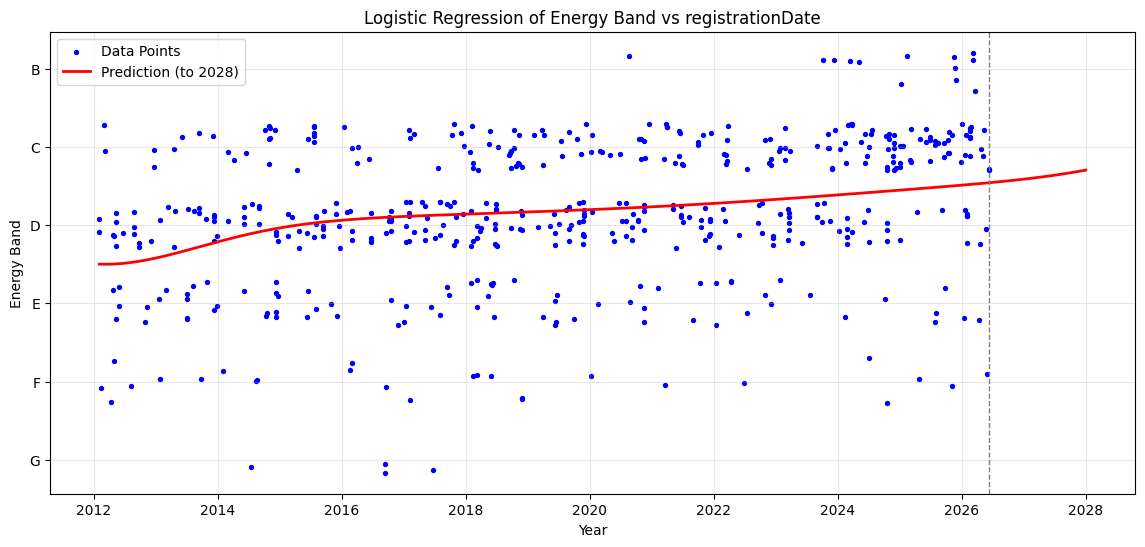

In [101]:

import warnings 
warnings.filterwarnings('ignore')

def plot_polynomial_regression(X, y, feature_name):
    
    # convert datetime to numeric
    X_squeeze = X.squeeze()
    min_date = X_squeeze.min()
    X_days = (X_squeeze - min_date).dt.days.values.reshape(-1, 1)

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_days)

    y_encoded = label_encode(y)

    train_model(X_poly, y_encoded)

    # make future prediction
    end_date = pd.Timestamp('2028-01-01')
    max_days = (end_date - min_date).days
    X_future_days = np.linspace(0, max_days, 500).reshape(-1, 1)
    X_future = poly.transform(X_future_days)

    probability = MODEL.predict_proba(X_future)

    class_indices = np.arange(len(BAND_ORDER))
    # average out the probabilites made with dot product
    y_future = probability @ class_indices

    # convert days back to years 
    min_year_offset = min_date.year + (min_date.month - 1) / 12 + (min_date.day - 1) / 365.25
    X_years = X_days.flatten() / 365.25 + min_year_offset
    X_future_years = X_future_days.flatten() / 365.25 + min_year_offset

    jitter = np.random.uniform(-0.3, 0.3, size=len(y_encoded))

    plt.figure(figsize=(14, 6))
    plt.scatter(
        X_years,
        y_encoded + jitter,
        color='blue', s=8, label='Data Points'
    )
    plt.plot(
        X_future_years,
        y_future,
        color='red', linewidth=2, label='Prediction (to 2028)'
    )

    data_cutoff = X_years.max()
    plt.axvline(data_cutoff, color='grey', linestyle='--', linewidth=1)

    plt.yticks(range(len(BAND_ORDER)), BAND_ORDER)
    plt.title(f'Logistic Regression of Energy Band vs {feature_name}')
    plt.xlabel('Year')
    plt.ylabel('Energy Band')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_polynomial_regression(school_frame[['registrationDate']], school_frame['currentEnergyEfficiencyBand'], 'registrationDate')